In [ ]:
# Imports

import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# **a. Load Dataset 'Iris (5).csv'**

In [ ]:
# Data

df = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/Iris%20(5).csv')
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
153,154,7.5,3.0,6.6,2.1,NaN
154,155,5.7,3.0,4.2,1.2,NaN
155,156,5.5,3.4,1.5,0.4,NaN
156,157,4.7,3.0,1.4,0.3,NaN


# **b. Drop unwanted columns that will not contribute to the prediction of 'Species'**

In [ ]:
df['Species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica', nan],
      dtype=object)

In [ ]:
new_df = df.drop(['Id'],axis=1,inplace=True)
new_df

In [ ]:
missing_data = df.isnull().sum()
missing_data

,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,8


In [ ]:
missing_species = df[df['Species'].isnull()]
missing_species

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
150,5.6,2.9,4.2,1.3,NaN
151,7.1,3.2,6.0,1.8,NaN
152,4.6,2.3,1.3,0.3,NaN
153,7.5,3.0,6.6,2.1,NaN
154,5.7,3.0,4.2,1.2,NaN
155,5.5,3.4,1.5,0.4,NaN
156,4.7,3.0,1.4,0.3,NaN
157,7.6,3.0,6.1,2.3,NaN


# **c. There are missing 'Species' data in the dataset with 'NaN' at index 150 to 157**
**Replace them scientifically based on existing data.
   It is better to check the closest (probable) values, this is crucial for the correct answer onwards.
   You are on you own with this one, replace the missing 'Species' (NaN) values based on the mean features by grouping (groupby) 'Species' and finding its mean (.mean())
   Replace missing 'Species' of data 150 to 157 from your corresponding analysis by using df.at[index, column] = ['Species Values']**

In [ ]:
mean_features_by_species = df.groupby('Species').mean()
mean_features_by_species

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Species,,,,
Iris-setosa,5.006,3.418,1.464,0.244
Iris-versicolor,5.936,2.770,4.260,1.326
Iris-virginica,6.588,2.974,5.552,2.026


In [ ]:
df.loc[150:157, 'Species'] = np.nan
means = df.dropna().groupby('Species').mean()

def find_closest_species(row):
    distances = means.apply(lambda mean_row: np.linalg.norm(row - mean_row), axis=1)
    return distances.idxmin()

for idx in range(150, 158):
    row = df.loc[idx, df.columns[:4]]  # select only feature columns
    closest_species = find_closest_species(row)
    df.at[idx, 'Species'] = closest_species

print(df.loc[150:157])

     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm          Species
150            5.6           2.9            4.2           1.3  Iris-versicolor
151            7.1           3.2            6.0           1.8   Iris-virginica
152            4.6           2.3            1.3           0.3      Iris-setosa
153            7.5           3.0            6.6           2.1   Iris-virginica
154            5.7           3.0            4.2           1.2  Iris-versicolor
155            5.5           3.4            1.5           0.4      Iris-setosa
156            4.7           3.0            1.4           0.3      Iris-setosa
157            7.6           3.0            6.1           2.3   Iris-virginica


# **d. Where applicable, use random_state = 50 for the model itself and for train_test_split**

In [ ]:
data_columns = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

# Select the feature columns X and the target column y
X = df[data_columns]
y = df['Species']

In [ ]:
X

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
153,7.5,3.0,6.6,2.1
154,5.7,3.0,4.2,1.2
155,5.5,3.4,1.5,0.4
156,4.7,3.0,1.4,0.3


In [ ]:
y

,Species
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa
...,...
153,Iris-virginica
154,Iris-versicolor
155,Iris-setosa
156,Iris-setosa


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=50)

dt_model = DecisionTreeClassifier(random_state=50)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=50)

In [ ]:
y_pred = dt_model.predict(X_test)
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        13
Iris-versicolor       0.79      1.00      0.88        11
 Iris-virginica       1.00      0.81      0.90        16

       accuracy                           0.93        40
      macro avg       0.93      0.94      0.93        40
   weighted avg       0.94      0.93      0.93        40



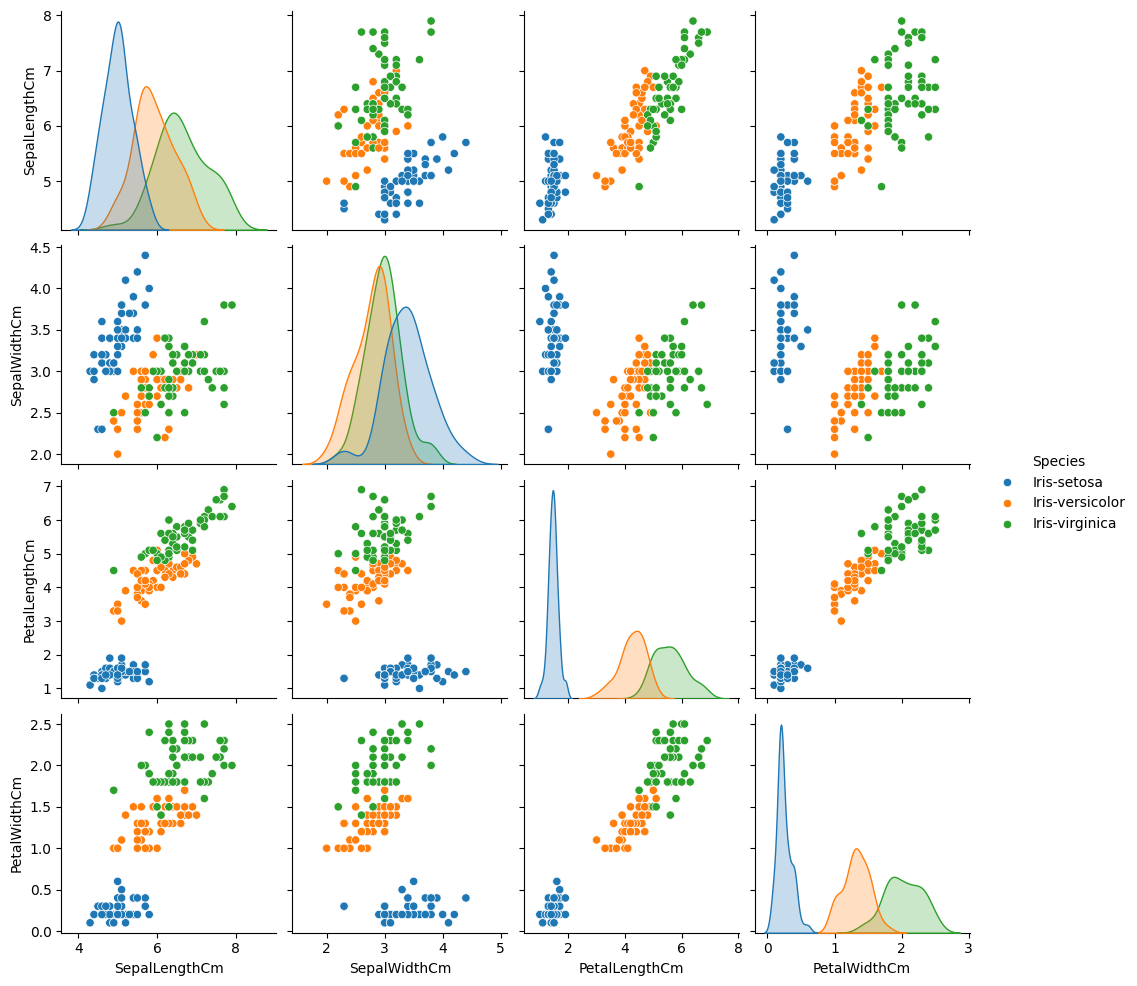

In [ ]:
# Pairplot

sns.pairplot(df, hue = 'Species')

# **e. Test size = 0.3**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=50)

dt_model = DecisionTreeClassifier(random_state=50)
dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        17
Iris-versicolor       0.81      1.00      0.90        13
 Iris-virginica       1.00      0.83      0.91        18

       accuracy                           0.94        48
      macro avg       0.94      0.94      0.94        48
   weighted avg       0.95      0.94      0.94        48



# **1. 	What is the accuracy of the Decision Tree model based on classification report?**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=50)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
print(classification_report(y_test, y_pred_dt))


                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        17
Iris-versicolor       0.81      1.00      0.90        13
 Iris-virginica       1.00      0.83      0.91        18

       accuracy                           0.94        48
      macro avg       0.94      0.94      0.94        48
   weighted avg       0.95      0.94      0.94        48



# **2. 	What is the Species on if I have [4.95, 2.9, 1.3, 0.1]**

In [ ]:
new_data0 = pd.DataFrame([[4.95, 2.9, 1.3, 0.1]], columns=X_train.columns)

predicted_species0 = dt_model.predict(new_data0)

print(f"The predicted species for the input [4.95, 2.9, 1.3, 0.1] is: {predicted_species0[0]}")

The predicted species for the input [4.95, 2.9, 1.3, 0.1] is: Iris-setosa


# **3. 	What is the Species on if I have [2.45, 3.9, 2.5, 0.2]**

In [ ]:
new_data1 = pd.DataFrame([[2.45, 3.9, 2.5, 0.2]], columns=X_train.columns)

predicted_species1 = dt_model.predict(new_data1)

print(f"The predicted species for the input [2.45, 3.9, 2.5, 0.2] is: {predicted_species1[0]}")

The predicted species for the input [2.45, 3.9, 2.5, 0.2] is: Iris-setosa


# **4.	What is the most important variable in the dataset for prediction?**

In [ ]:
from sklearn.linear_model import LogisticRegression

feature_importances = pd.Series(dt_model.feature_importances_, index=X_train.columns)
most_important_variable = feature_importances.sort_values(ascending=False).index[0]

print(f"The most important variable for prediction is: {most_important_variable}")

The most important variable for prediction is: PetalWidthCm


# **5.      How many terminal nodes from your generated Decision Tree?**

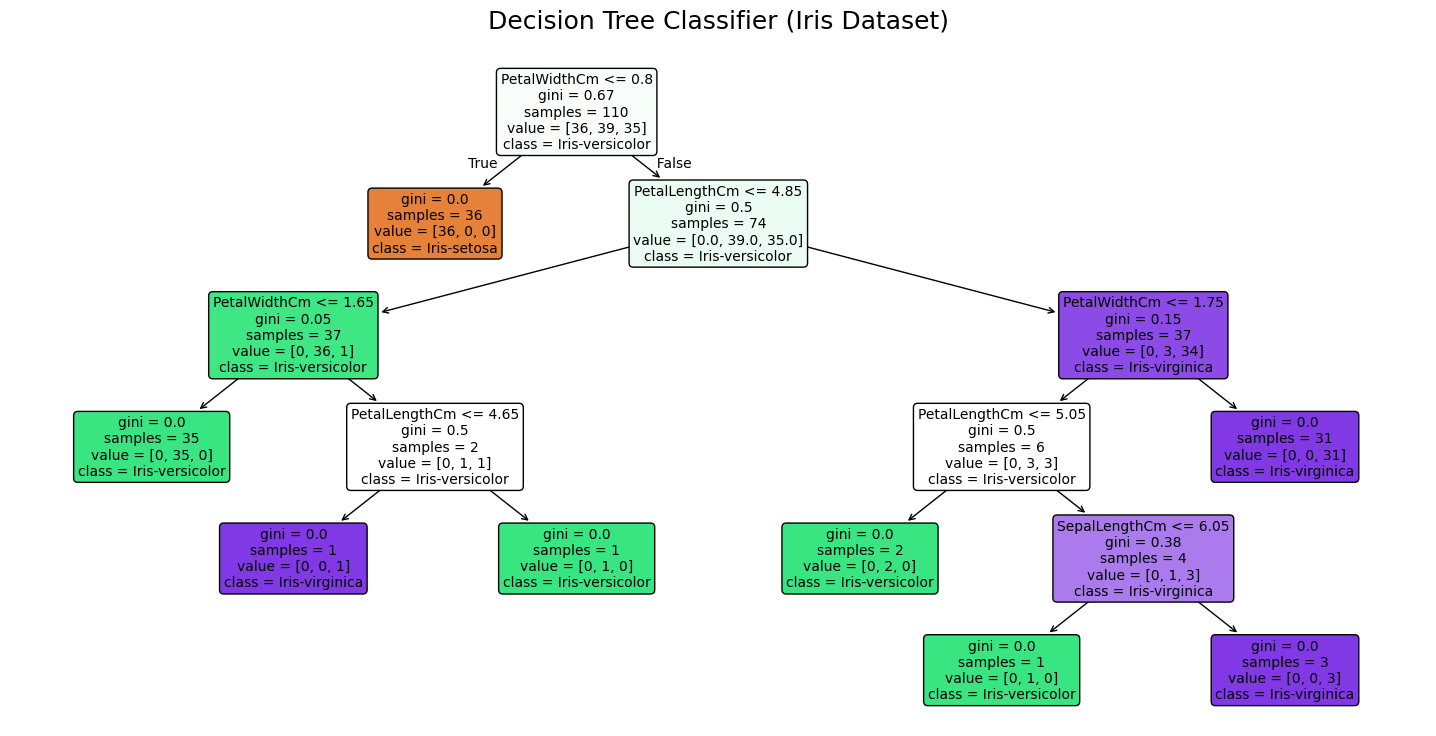

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Adjust figure size to be more balanced for visibility
plt.figure(figsize=(15, 8))  # Slightly wider and taller for deep trees

plot_tree(
    dt_model,
    filled=True,
    feature_names=X.columns,
    class_names=dt_model.classes_,
    rounded=True,
    proportion=False,
    precision=2,
    fontsize=10,             # Slightly smaller font to avoid overlap
    impurity=True
)

plt.title("Decision Tree Classifier (Iris Dataset)", fontsize=18, pad=20)
plt.tight_layout(pad=3.0)     # Add spacing around edges
plt.show()


In [ ]:
n_nodes = dt_model.tree_.node_count
children_left = dt_model.tree_.children_left
children_right = dt_model.tree_.children_right

is_leaf = (children_left == -1) & (children_right == -1)
terminal_nodes = n_nodes - sum(~is_leaf)

print(f"The number of terminal nodes (leaves) in the Decision Tree is: {terminal_nodes}")

The number of terminal nodes (leaves) in the Decision Tree is: 8
